## **Testing LEM-X pointing**

CAM1H
  Crab Source Position in the camera local-frame coords
  - shifts: (-52.55320588166768, -56.199841769251)
  - angles: (np.float64(-14.510818374736035), np.float64(-15.470935671066176))
  - RA - DEC: CoordEquatorial(ra=83.6332015991211, dec=22.014499664306626)
  - CAM pointings: {'z': CoordEquatorial(ra=65.6737015953277, dec=35.6486362123488), 'x': CoordEquatorial(ra=257.33165649948, dec=53.7838910823791)}
  - Wanted CAM pointings: CoordEquatorial(ra=83.1078519664901, dec=21.540083357047777)



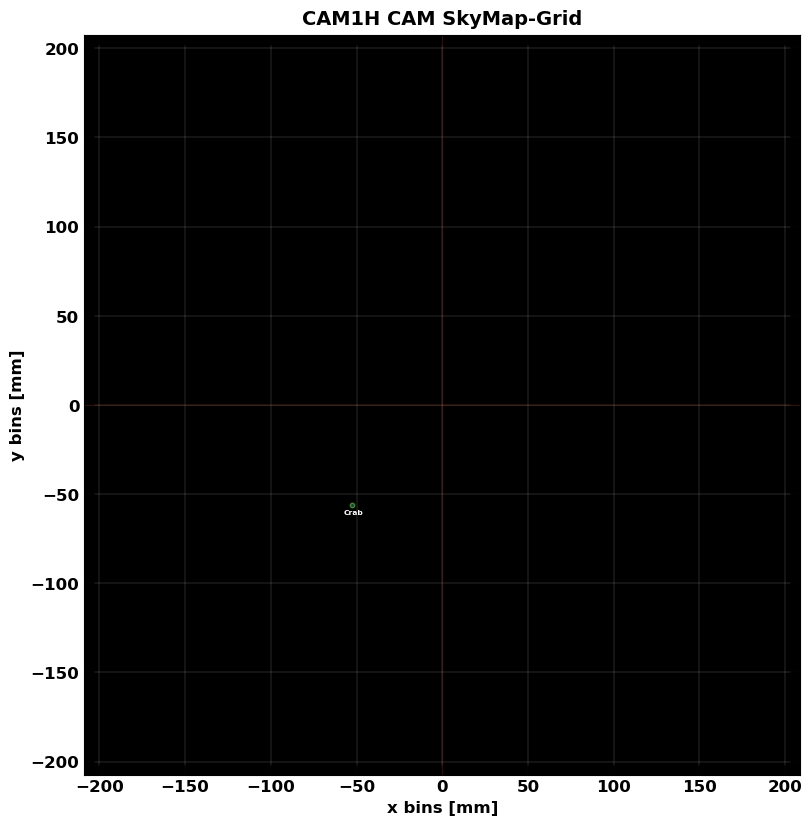

In [ ]:
from pathlib import Path

from bloodmoon.coords import equatorial2shift, shift2angle, shift2equatorial, angle2shift
from bloodmoon.mask import codedmask, count, decode

import darksun as ds
from darksun.types import LogEntry
from darksun.show import skyfield_map


# setup mask and data
base_path = '/home/edoardo/Datadisk/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
skyfield = 'Crab/PointingTests'
mask_FITS = 'wfm_mask_NTHT_20250725.fits'
data_FITS = 'test_camera_tilt'
filepath = f'{base_path}/{skyfield}/{data_FITS}'

UPX, UPY = 1, 1
wfm = codedmask(f'{base_path}/{mask_FITS}', UPX, UPY)

CrabRA = 83.6332015991211
CrabDEC = 22.0144996643066
cameras = tuple(p.name for p in Path(filepath).glob('*cam1h*') if p.is_dir())


for camID in cameras:
    sdlA = ds.get_data(f'{filepath}/{camID}/{data_FITS}_{camID}_detected.fits')
    detector, _ = count(wfm, sdlA.DLdata)
    sky = decode(wfm, detector)
    shiftx, shifty = equatorial2shift(sdlA, wfm, CrabRA, CrabDEC)
    thetax, thetay = tuple(map(lambda x: shift2angle(wfm, x), (shiftx, shifty)))
    print(
        f'{camID.upper()}\n'
        f'  Crab Source Position in the camera local-frame coords\n'
        f'  - shifts: {shiftx, shifty}\n'
        f'  - angles: {thetax, thetay}\n'
        f'  - RA - DEC: {shift2equatorial(sdlA, wfm, shiftx, shifty)}\n'
        f'  - CAM pointings: {sdlA.pointings}\n'
        f'  - Wanted CAM pointings: {shift2equatorial(
            sdlA, wfm, angle2shift(wfm, -15.0), angle2shift(wfm, -15.0),
        )}\n'
    )

    # show source position in skymap
    params = (
        LogEntry('ID', '20A', ''), LogEntry('shift_x', 'D', 'mm'), LogEntry('shift_y', 'D', 'mm'),
    )
    source_log = ds.create_log(
        params=params,
        name=f'{camID} CAM'
    )
    source_log.update(tuple((p.entry, val) for p, val in zip(params, ('Crab', shiftx, shifty))))
    skyfield_map(
        log=source_log,
        camera=wfm,
    )